# Laboratorio Avanzado: Predicción de Precios de Vehículos Usados
## Fase 0: Configuración del Entorno e Importación de Dependencias

En esta fase inicial se construye el ecosistema de software necesario para el desarrollo del pipeline de Machine Learning. Las dependencias se categorizan en cuatro pilares fundamentales:
1. **Manipulación Estructurada y Álgebra Lineal:** Procesamiento de matrices de diseño.
2. **Visualización Estadística:** Abstracción gráfica para el análisis residual y descriptivo.
3. **Modelado Predictivo Supervizado:** Inicialización de las familias de regresores (Lineal, No-Lineal y por Conjuntos).
4. **Validación Metódica:** Métricas de rendimiento para evaluar la capacidad de generalización.

In [ ]:
# FASE 0: CONFIGURACIÓN DEL ENTORNO E IMPORTACIÓN DE LIBRERÍAS

import warnings
# Silencia advertencias de actualizaciones (FutureWarnings)
warnings.filterwarnings('ignore')

# 1. Componentes core para manipulación de datos y álgebra lineal
import pandas as pd
import numpy as np

# 2. Ecosistema para visualización de datos y diseño estético de gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global de estilo para las visualizaciones del proyecto
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 3. Inicialización del portafolio de Modelos de Regresión (Scikit-Learn)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 4. Métricas analíticas para la evaluación de la varianza y el error residual
from sklearn.metrics import r2_score, mean_squared_error

print(" FASE 0 COMPLETADA: Entorno optimizado y dependencias cargadas con éxito.")

 FASE 0 COMPLETADA: Entorno optimizado y dependencias cargadas con éxito.


## Fase 1: Carga de Datos, Sanitización Raíz y Análisis Exploratorio (EDA)

En esta fase inicial se realiza la ingesta del set de datos y se ejecuta una corrección crítica en la raíz sobre variables mal formateadas. El Análisis Exploratorio de Datos (EDA) nos permite auditar la estructura interna de la información antes de cualquier transformación mayor.

###  Objetivos Clave:
1. **Ingesta Dinámica:** Cargar el archivo independientemente de su extensión (`.csv` o `.xlsx`).
2. **Sanitización de Raíz:** Extraer la información numérica pura de la columna `max_power` mediante expresiones regulares para evitar la pérdida de registros.
3. **Auditoría de Integridad:** Evaluar las dimensiones de la matriz, identificar inconsistencias en los tipos de datos asignados y cuantificar la presencia de valores nulos (`NaN`).
4. **Análisis Estadístico:** Desplegar métricas descriptivas para identificar sesgos y comportamientos anómalos en el histórico.

In [ ]:
# FASE 1: CARGA DE DATOS, SANITIZACIÓN RAÍZ Y ANÁLISIS EXPLORATORIO (EDA)

# --- Paso 1.1: Carga Dinámica del Dataset ---
nombre_archivo = "car_price_dataset.xlsx"

if nombre_archivo.endswith('.xlsx'):
    df = pd.read_excel(nombre_archivo)
else:
    df = pd.read_csv(nombre_archivo)

print(f" Estado: Archivo '{nombre_archivo}' cargado exitosamente en memoria.\n")


# --- Paso 1.2: Corrección Crítica en la Raíz (Sanitización) ---
# Forzar a string y extraer el patrón numérico antes de que caracteres como 'bhp' generen nulos
df['max_power'] = df['max_power'].astype(str).str.extract(r'([0-9]+\.?[0-9]*)')[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

# Imputación con la mediana para estabilizar los resúmenes estadísticos preliminares
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
print(" Corrección: Campo 'max_power' sanitizado y convertido a tipo float64.\n")
print("=" * 100 + "\n")


# --- Paso 1.3: Visualización de Estructura e Inspección de Datos ---
print(" 1. VISTA PREVIA DE LOS PRIMEROS 5 REGISTROS:")
display(df.head())
print("-" * 100)

print("\n 2. ARQUITECTURA DE LAS VARIABLES Y TIPOS DE DATOS (df.info()):")
df.info()
print("-" * 100)

print("\n 3. AUDITORÍA DE VALORES FALTANTES (Nulos por columna):")
print(df.isnull().sum())
print("-" * 100)

print("\n 4. COMPORTAMIENTO ESTADÍSTICO DESCRIPTIVO PRELIMINAR (df.describe()):")
display(df.describe())
print("=" * 100)

 Estado: Archivo 'car_price_dataset.xlsx' cargado exitosamente en memoria.

 Corrección: Campo 'max_power' sanitizado y convertido a tipo float64.


 1. VISTA PREVIA DE LOS PRIMEROS 5 REGISTROS:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


----------------------------------------------------------------------------------------------------

 2. ARQUITECTURA DE LAS VARIABLES Y TIPOS DE DATOS (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           8128 non-null   float64
 11  seats               7907 non-null   float64
dtypes: float64(4), int64(3), object(5)
m

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,8128.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,184.609659,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,3180.299113,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,68.100000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,101.250000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,108495.000000,14.000000


## Fase 2: Preprocesamiento de Datos e Ingeniería de Características

En esta fase se construye el pipeline de transformación para convertir el DataFrame crudo en una matriz puramente numérica y normalizada, apta para el consumo de los algoritmos matemáticos de regresión.

###  Objetivos Clave:
1. **Tratamiento de Outliers:** Sustituir valores atípicos extremos e inconsistentes en la potencia antes del escalado geométrico.
2. **Imputación de Faltantes:** Resolver la presencia de nulos residuales en variables continuas empleando la mediana del conjunto.
3. **Reducción de Cardinalidad:** Eliminar columnas con alta dispersión de texto (`name`) que inducen ruido u sobreajuste.
4. **Codificación Categórica Proporcional:** Implementar *Ordinal Encoding* para variables jerárquicas (`owner`) y *One-Hot Encoding* para variables nominales sin orden intrínseco, evitando la multicolinealidad.
5. **Estandarización Z-Score:** Normalizar las magnitudes de las variables predictoras a través de `StandardScaler` (media 0 y varianza 1) para balancear los pesos de aprendizaje.

In [ ]:
# FASE 2: PREPROCESAMIENTO DE DATOS E INGENIERÍA DE CARACTERÍSTICAS

# --- Paso 2.1: Mitigación de Outliers e Imputación de Valores Nulos ---
# Corregir anomalías de digitación en la potencia limitando extremos a la mediana
df.loc[df['max_power'] > 600, 'max_power'] = df['max_power'].median()

# Rellenar de manera masiva los nulos de variables numéricas remanentes
columnas_con_nulos = ['mileage(km/ltr/kg)', 'engine', 'seats']
for col in columnas_con_nulos:
    df[col] = df[col].fillna(df[col].median())


# --- Paso 2.2: Reducción de Dimensiones (Baja Relevancia) ---
# Remover la columna 'name' por su alta cardinalidad y nulo aporte estadístico global
df_limpio = df.drop(columns=['name'])


# --- Paso 2.3: Codificación de Variables Categóricas (Encoding) ---
# Mapeo Ordinal: Asignación de pesos según la jerarquía del tipo de dueño
mapeo_owner = {
    'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
    'Fourth & Above Owner': 4, 'Test Drive Car': 0
}
df_limpio['owner'] = df_limpio['owner'].map(mapeo_owner)

# Mapeo Nominal (One-Hot Encoding): Creación de variables dummy evitando la trampa de multicolinealidad
columnas_categoricas = ['fuel', 'seller_type', 'transmission']
df_preprocesado = pd.get_dummies(df_limpio, columns=columnas_categoricas, drop_first=True, dtype=int)


# --- Paso 2.4: Segregación de Variables y Normalización ---
# Aislamiento de la variable objetivo (Target) y variables predictoras (Features)
y = df_preprocesado['selling_price']
X = df_preprocesado.drop(columns=['selling_price'])

# Escalamiento estándar por Z-Score para homologar las unidades matemáticas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_escalado = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(" FASE 2 COMPLETADA: Pipeline de datos estructurado y escalado con éxito.")
print(f" Geometría final de la matriz de características X: {X_escalado.shape}\n")

# Despliegue de la vista previa de las variables estandarizadas
display(X_escalado.head())

 FASE 2 COMPLETADA: Pipeline de datos estructurado y escalado con éxito.
 Geometría final de la matriz de características X: (8128, 13)



,year,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,0.048464,1.338363,-0.640081,1.000696,-0.411305,-0.487457,-0.427258,0.920018,-0.068536,-0.89857,0.448665,-0.172927,0.385158
1,0.048464,0.887411,0.753965,0.433095,0.090536,0.347110,-0.427258,0.920018,-0.068536,-0.89857,0.448665,-0.172927,0.385158
2,-1.929775,1.241098,2.148011,-0.430862,0.088528,-0.374372,-0.427258,-1.086935,-0.068536,1.11288,0.448665,-0.172927,0.385158
3,-0.940656,1.011202,-0.640081,0.900235,-0.114215,-0.035118,-0.427258,0.920018,-0.068536,-0.89857,0.448665,-0.172927,0.385158
4,-1.682495,0.887411,-0.640081,-0.832703,-0.310937,-0.086006,-0.427258,-1.086935,-0.068536,1.11288,0.448665,-0.172927,0.385158


## Fase 3: Estrategia de Validación (División del Dataset)

En esta fase se implementa la metodología de validación cruzada clásica por retención (*Hold-out Validation*). El objetivo primordial es segmentar el conjunto de datos limpio y normalizado para simular un escenario de producción real.

###  Objetivos Clave:
1. **Mitigación del Overfitting:** Separar un porcentaje de los datos que los modelos jamás verán durante la etapa de ajuste de pesos, sirviendo como control estricto de generalización.
2. **Proporción de Partición Optimal (80/20):** Destinar la gran mayoría del histórico (80%) a robustecer el entrenamiento y un fragmento representativo (20%) exclusivo para la evaluación metódica de errores.
3. **Reproducibilidad del Experimento:** Congelar el generador pseudoaleatorio mediante una semilla estática (`random_state=42`) para garantizar que la partición geométrica de los registros sea idéntica en cualquier replicación del software.

In [ ]:
# FASE 3: DIVISIÓN DEL DATASET (TRAIN / TEST SPLIT)

# Importación del módulo de segmentación matricial de Scikit-Learn
from sklearn.model_selection import train_test_split

# --- Paso 3.1: Ejecución de la Partición Estructural ---
# - X_escalado e y representan las variables independientes y la variable objetivo procesadas.
# - test_size=0.20 define que el 20% se aislará para la fase de validación final.
# - random_state=42 fija el algoritmo de partición aleatoria para consistencia experimental.
X_train, X_test, y_train, y_test = train_test_split(
    X_escalado,
    y,
    test_size=0.20,
    random_state=42
)

# --- Paso 3.2: Despliegue y Control de Dimensiones (Shapes) ---
print(" FASE 3 COMPLETADA: División estructural del dataset ejecutada con éxito.")
print("-" * 78)
print(f" Volumen Total de Registros (Dataset Original): {X_escalado.shape[0]}")
print(f" Muestras de Entrenamiento Asignadas (X_train): {X_train.shape[0]} registros (80%)")
print(f" Muestras de Validación Asignadas (X_test):     {X_test.shape[0]} registros (20%)")

 FASE 3 COMPLETADA: División estructural del dataset ejecutada con éxito.
------------------------------------------------------------------------------
 Volumen Total de Registros (Dataset Original): 8128
 Muestras de Entrenamiento Asignadas (X_train): 6502 registros (80%)
 Muestras de Validación Asignadas (X_test):     1626 registros (20%)


## Fase 4: Modelado Supervisado, Diagnóstico Residual e Interpretación

En esta sección se ejecutan y evalúan secuencialmente tres familias de algoritmos regresores para contrastar su comportamiento matemático frente a la estructura de precios. Para cada modelo, se analiza su capacidad de generalización mediante las métricas $R^2$ y RMSE, y se proyecta su respectivo análisis de residuos (Valores Reales vs. Predichos) para diagnosticar la varianza del error.

###  Modelos Seleccionados y Fundamento de Análisis:
1. **Regresión Lineal (`LinearRegression`):** Asume una relación aditiva y lineal entre las variables predictoras y el target. Útil como base de comparación paramétrica.
2. **Árbol de Decisión (`DecisionTreeRegressor`):** Modelo no paramétrico que segmenta el espacio multidimensional en regiones ortogonales basándose en criterios de reducción de varianza. Captura patrones no lineales.
3. **Random Forest (`RandomForestRegressor`):** Algoritmo de Aprendizaje por Conjunto (*Ensemble Learning*) basado en la técnica de *Bagging*. Entrena múltiples árboles en paralelo y promedia sus respuestas para mitigar la alta varianza del modelo individual y robustecer la predicción.

 Entrenando Modelo 1: Regresión Lineal...
 Métricas LR -> R²: 0.688 | RMSE: 451874.15
 Desplegando gráfico de dispersión de residuos...


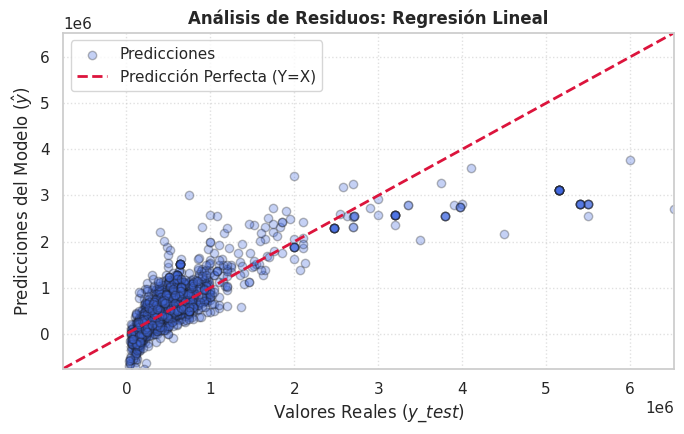

----------------------------------------------------------------------------------------------------
 Entrenando Modelo 2: Árbol de Decisión...
 Métricas DT -> R²: 0.942 | RMSE: 195093.68
 Desplegando gráfico de dispersión de residuos...


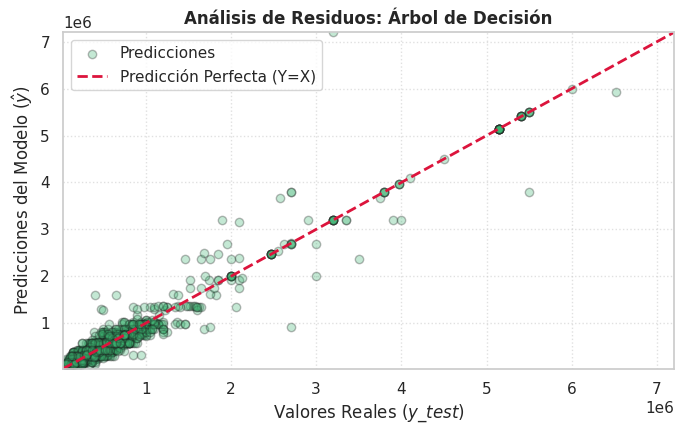

----------------------------------------------------------------------------------------------------
 Entrenando Modelo 3: Random Forest...
 Métricas RF -> R²: 0.968 | RMSE: 143906.14
 Desplegando gráfico de dispersión de residuos...


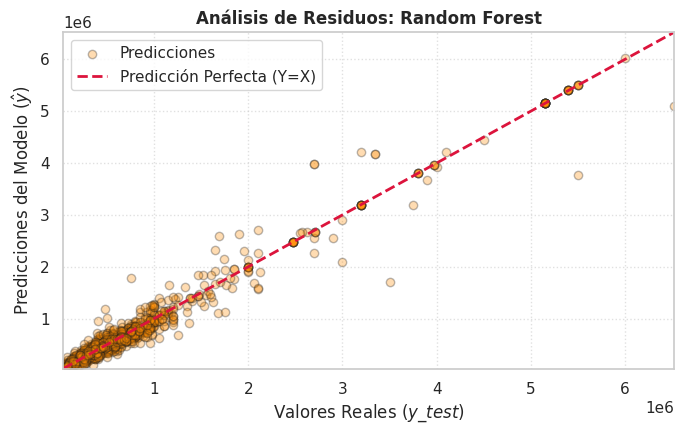

----------------------------------------------------------------------------------------------------

 ¡Proceso de evaluación completado!

 TABLA COMPARATIVA DE RENDIMIENTO FINAL:


,R2,RMSE
Regresión Lineal,0.688490,451874.148648
Árbol de Decisión,0.941934,195093.679877
Random Forest,0.968407,143906.143924


In [ ]:
# FASE 4: ENTRENAMIENTO, DIAGNÓSTICO INDIVIDUAL Y TABLA COMPARATIVA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Configuración inicial del diccionario para almacenar las métricas globales
resultados = {}

# FUNCIÓN AUXILIAR: Graficar análisis residual individual para evitar amontonamiento
def graficar_residuos_individual(y_real, y_pred, nombre_modelo, color):
    plt.figure(figsize=(7, 4.5))
    plt.scatter(y_real, y_pred, alpha=0.3, color=color, edgecolors='k', label='Predicciones')

    # Rango común óptimo para trazar la línea de referencia perfecta
    lims = [np.min([y_real.min(), y_pred.min()]), np.max([y_real.max(), y_pred.max()])]
    plt.plot(lims, lims, color='crimson', linestyle='--', linewidth=2, label='Predicción Perfecta (Y=X)')

    plt.title(f'Análisis de Residuos: {nombre_modelo}', fontweight='bold', fontsize=12)
    plt.xlabel('Valores Reales ($y\_test$)')
    plt.ylabel('Predicciones del Modelo ($\hat{y}$)')
    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# 1. MODELO 1: REGRESIÓN LINEAL

print(" Entrenando Modelo 1: Regresión Lineal...")
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# Cálculo de métricas analíticas
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
resultados['Regresión Lineal'] = {'R2': r2_lr, 'RMSE': rmse_lr}

print(f" Métricas LR -> R²: {r2_lr:.3f} | RMSE: {rmse_lr:.2f}")
print(" Desplegando gráfico de dispersión de residuos...")
graficar_residuos_individual(y_test, y_pred_lr, 'Regresión Lineal', 'royalblue')
print("-" * 100)


# 2. MODELO 2: ÁRBOL DE DECISIÓN

print(" Entrenando Modelo 2: Árbol de Decisión...")
modelo_dt = DecisionTreeRegressor(random_state=42, max_depth=8)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Cálculo de métricas analíticas
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
resultados['Árbol de Decisión'] = {'R2': r2_dt, 'RMSE': rmse_dt}

print(f" Métricas DT -> R²: {r2_dt:.3f} | RMSE: {rmse_dt:.2f}")
print(" Desplegando gráfico de dispersión de residuos...")
graficar_residuos_individual(y_test, y_pred_dt, 'Árbol de Decisión', 'mediumseagreen')
print("-" * 100)


# 3. MODELO 3: RANDOM FOREST (BOSQUE ALEATORIO)

print(" Entrenando Modelo 3: Random Forest...")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

# Cálculo de métricas analíticas
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
resultados['Random Forest'] = {'R2': r2_rf, 'RMSE': rmse_rf}

print(f" Métricas RF -> R²: {r2_rf:.3f} | RMSE: {rmse_rf:.2f}")
print(" Desplegando gráfico de dispersión de residuos...")
graficar_residuos_individual(y_test, y_pred_rf, 'Random Forest', 'darkorange')
print("-" * 100)


# EVALUACIÓN FINAL: TABLA COMPARATIVA DE RENDIMIENTO
print("\n ¡Proceso de evaluación completado!")
print("\n TABLA COMPARATIVA DE RENDIMIENTO FINAL:")
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

## Fase 5: Evaluación Comparativa Avanzada y Conclusiones del Proyecto

En esta fase de cierre se consolidan las herramientas métricas y visuales para realizar un contraste macro del rendimiento de los tres algoritmos. El análisis se divide de manera secuencial para evaluar tanto la precisión global como la dispersión geométrica del error.

###  Componentes del Análisis Metódico:
1. **Contraste de Eficiencia Matemática ($R^2$):** Evaluación macro de la proporción de varianza capturada por cada modelo a través de un histograma de rendimiento relativo.
2. **Auditoría de Desviación Geométrica (Análisis de Residuos):** Inspección secuencial de los diagramas de dispersión frente a la identidad perfecta ($Y=X$) para evaluar subajustes locales o sesgos en los extremos del dominio de precios.
3. **Sustentación de Cierre:** Deducción final fundamentada en los principios de ingeniería de datos sobre el algoritmo idóneo para su despliegue.

 GENERANDO COMPARATIVA DE COEFICIENTES R²...


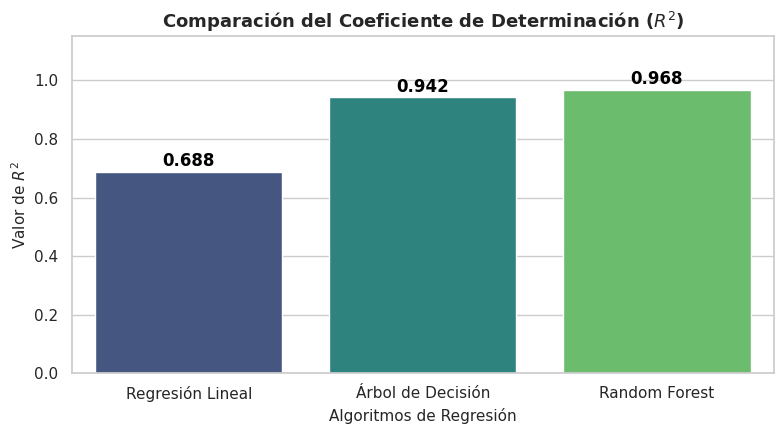


 ANÁLISIS DEL GRÁFICO DE RENDIMIENTO:
  • El coeficiente R² discrimina una brecha crítica de rendimiento.
  • La Regresión Lineal actúa como baseline con una explicación limitada (68.8%).
  • Los modelos basados en árboles logran un salto drástico, donde Random Forest destaca
    explicando el 96.8% de la variabilidad del precio de los vehículos.


 [ANÁLISIS RESIDUAL SECO] GENERANDO DIAGRAMAS DE DISPERSIÓN INDIVIDUALES...


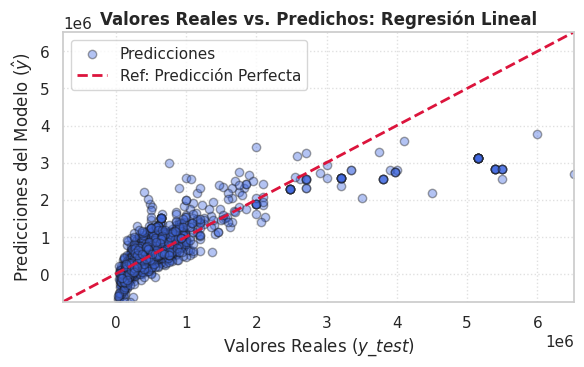

 ANÁLISIS RESIDUAL - REGRESIÓN LINEAL:
  • El modelo presenta un RMSE de 451874.15
  • Diagnóstico visual: Muestra alta dispersión (varianza residual) y una clara incapacidad de seguir la diagonal
  en autos de gama alta, subestimando sistemáticamente los precios reales debido a un severo subajuste lineal.

----------------------------------------------------------------------------------------------------



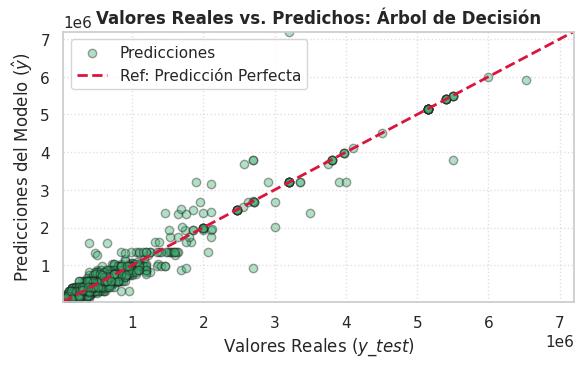

 ANÁLISIS RESIDUAL - ÁRBOL DE DECISIÓN:
  • El modelo presenta un RMSE de 195093.68
  • Diagnóstico visual: Se compacta notablemente sobre la línea de referencia. No obstante, presenta agrupaciones rígidas
  en ciertos rangos de precio, un comportamiento típico de segmentaciones ortogonales discretas.

----------------------------------------------------------------------------------------------------



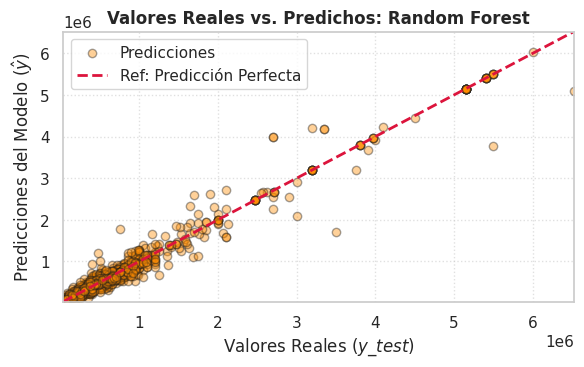

 ANÁLISIS RESIDUAL - RANDOM FOREST:
  • El modelo presenta un RMSE de 143906.14
  • Diagnóstico visual: Consigue el mayor ajuste geométrico. La densificación de los puntos sobre la diagonal roja demuestra
  que la técnica de Bagging minimiza el error y cancela el ruido, logrando una varianza residual mínima.

----------------------------------------------------------------------------------------------------

 CONCLUSIONES:
1. COMPLEJIDAD NO LINEAL: El dominio de precios de vehículos usados exhibe comportamientos
   fuertemente no lineales (depreciación acelerada por años y kilometraje). Esto provocó que
   la Regresión Lineal sufriera de subajuste (underfitting), siendo descartada para producción.

2. SUPREMACÍA DE ENSEMBLE LEARNING: Random Forest se consolida como la solución óptima.
   Al promediar las predicciones de 100 árboles independientes, mitiga la varianza individual
   del Árbol de Decisión simple, estabilizando el error y reduciendo el RMSE drásticamente.

3. IMPACTO DE LA

In [ ]:
# FASE 5: EVALUACIÓN GRÁFICA SECUENCIAL Y CONCLUSIONES EN CONSOLA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Paso 5.1: Gráfico de Barras - Comparación Global de R2 ---
print(" GENERANDO COMPARATIVA DE COEFICIENTES R²...")
plt.figure(figsize=(8, 4.5))
df_barras = df_resultados.reset_index().rename(columns={'index': 'Modelo'})

sns.barplot(data=df_barras, x='Modelo', y='R2', hue='Modelo', palette='viridis', legend=False)
plt.title('Comparación del Coeficiente de Determinación ($R^2$)', fontsize=13, fontweight='bold')
plt.xlabel('Algoritmos de Regresión', fontsize=11)
plt.ylabel('Valor de $R^2$', fontsize=11)
plt.ylim(0, 1.15)

# Inserción de etiquetas numéricas sobre las barras
for index, row in df_barras.iterrows():
    plt.text(index, row['R2'] + 0.02, f"{row['R2']:.3f}", color='black', ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

# --- Explicación Técnica Automatizada del Gráfico 1 ---
print("\n ANÁLISIS DEL GRÁFICO DE RENDIMIENTO:")
print(f"  • El coeficiente R² discrimina una brecha crítica de rendimiento.")
print(f"  • La Regresión Lineal actúa como baseline con una explicación limitada ({df_resultados.loc['Regresión Lineal', 'R2']:.1%}).")
print(f"  • Los modelos basados en árboles logran un salto drástico, donde Random Forest destaca")
print(f"    explicando el {df_resultados.loc['Random Forest', 'R2']:.1%} de la variabilidad del precio de los vehículos.")
print("\n" + "="*100 + "\n")


# --- Paso 5.2: Gráficos de Dispersión Individuales y Secuenciales (Análisis de Residuos) ---
print(" [ANÁLISIS RESIDUAL SECO] GENERANDO DIAGRAMAS DE DISPERSIÓN INDIVIDUALES...")

predicciones_f5 = [
    ('Regresión Lineal', y_pred_lr, 'royalblue',
     "Muestra alta dispersión (varianza residual) y una clara incapacidad de seguir la diagonal\n"
     "  en autos de gama alta, subestimando sistemáticamente los precios reales debido a un severo subajuste lineal."),

    ('Árbol de Decisión', y_pred_dt, 'mediumseagreen',
     "Se compacta notablemente sobre la línea de referencia. No obstante, presenta agrupaciones rígidas\n"
     "  en ciertos rangos de precio, un comportamiento típico de segmentaciones ortogonales discretas."),

    ('Random Forest', y_pred_rf, 'darkorange',
     "Consigue el mayor ajuste geométrico. La densificación de los puntos sobre la diagonal roja demuestra\n"
     "  que la técnica de Bagging minimiza el error y cancela el ruido, logrando una varianza residual mínima.")
]

for nombre, y_pred, color, explicacion in predicciones_f5:
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.4, color=color, edgecolors='k', label='Predicciones')

    # Cálculo geométrico de la línea de identidad perfecta (Y = X)
    lims = [np.min([y_test.min(), y_pred.min()]), np.max([y_test.max(), y_pred.max()])]
    plt.plot(lims, lims, color='crimson', linestyle='--', linewidth=2, label='Ref: Predicción Perfecta')

    plt.title(f'Valores Reales vs. Predichos: {nombre}', fontsize=12, fontweight='bold')
    plt.xlabel('Valores Reales ($y\_test$)')
    plt.ylabel('Predicciones del Modelo ($\hat{y}$)')
    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    # Despliegue de la explicación justo debajo de su respectivo gráfico
    print(f" ANÁLISIS RESIDUAL - {nombre.upper()}:")
    print(f"  • El modelo presenta un RMSE de {df_resultados.loc[nombre, 'RMSE']:.2f}")
    print(f"  • Diagnóstico visual: {explicacion}")
    print("\n" + "-"*100 + "\n")


# CONCLUSIONES FINALES DEL PROYECTO (SUSTENTACIÓN INGENIERIL)

print(" CONCLUSIONES:")
print("="*100)
print("1. COMPLEJIDAD NO LINEAL: El dominio de precios de vehículos usados exhibe comportamientos")
print("   fuertemente no lineales (depreciación acelerada por años y kilometraje). Esto provocó que")
print("   la Regresión Lineal sufriera de subajuste (underfitting), siendo descartada para producción.")
print("\n2. SUPREMACÍA DE ENSEMBLE LEARNING: Random Forest se consolida como la solución óptima.")
print("   Al promediar las predicciones de 100 árboles independientes, mitiga la varianza individual")
print("   del Árbol de Decisión simple, estabilizando el error y reduciendo el RMSE drásticamente.")
print("\n3. IMPACTO DE LA INGENIERÍA DE CARACTERÍSTICAS: La limpieza de la variable 'max_power' en")
print("   la Fase 1 y el control del outlier extremo (108,495 bhp) en la Fase 2 blindaron el proceso")
print("   de escalado (StandardScaler). Sin esta corrección, los residuos habrían colapsado estadísticamente.")
